### Step 1 - Load Telemetry Data

In [2]:
import pandas as pd

df = pd.read_csv("raceday1_telemetry.csv")
df.head()

,Time,bms.lowest_bank_voltage_*0.1mV.mean,bms.pack_voltage_V.mean,left_mcc.left_mcc_rpm.mean,riedon.riedon_current_mA.mean,right_mcc.right_mcc_rpm.mean,petals.can_pedal_pos.accelPos,petals.can_pedal_pos.brakePos,petals.can_pedal_pos.mechBrake
0,1751562000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1751562001000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1751562002000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1751562003000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1751562004000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Step 2 - Cleaning

In [4]:
df.columns = ["time", "vmin_raw", "vpack", "rpm_left", "current_mA",
              "rpm_right", "accel", "brake", "mech_brake"]

In [5]:
df["time"] = (pd.to_datetime(df["time"], unit="ms", utc=True)
              .dt.tz_convert("America/New_York")
              .dt.tz_localize(None))
df = df.set_index("time")

In [6]:
df["vmin"] = df["vmin_raw"] / 10_000
df["current"] = df["current_mA"] / 1000

In [7]:
df[["current", "accel"]].corr()
df["current"] = -df["current"]

In [8]:
bad = ~df["vmin"].between(2.5, 4.3) & df["vmin"].notna()
print(bad.sum(), "glitches removed")
df.loc[bad, "vmin"] = float("nan")

1 glitches removed


<Axes: xlabel='time'>

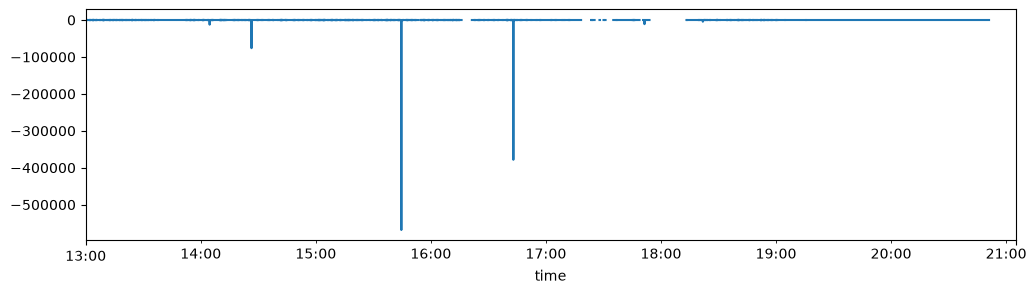

In [9]:
df["current"].plot(figsize=(12, 3))

### Step 3 - Load Lab Time Data

In [11]:
TIMING_CSV = "FSGP_Electronic_Timing_Day_1.csv"

laps = pd.read_csv(TIMING_CSV, skiprows=3)
laps.columns = ["lap", "start", "finish", "lap_time", "pit_min", "lap_min",
                "official_mph", "driver", "p1", "p2", "p3", "comments"]
laps = laps[["lap", "start", "finish", "pit_min", "official_mph", "driver", "comments"]]
laps.head(20)

,lap,start,finish,pit_min,official_mph,driver,comments
0,1,NaN,10:17:02,NaN,31.615,Evelyn Chuang,NaN
1,2,NaN,10:22:34,0.000,33.614,NaN,NaN
2,3,NaN,10:28:24,0.000,31.886,NaN,NaN
3,4,NaN,10:34:37,0.000,29.920,NaN,NaN
4,5,NaN,10:41:19,0.000,27.761,NaN,NaN
5,6,NaN,10:47:01,0.000,32.632,NaN,NaN
6,7,NaN,10:53:00,0.000,31.086,NaN,NaN
7,8,NaN,10:58:51,0.000,31.795,NaN,NaN
8,9,NaN,11:04:45,0.000,31.525,NaN,NaN
9,10,NaN,11:10:41,0.000,31.348,NaN,NaN


In [12]:
laps["driver"] = laps["driver"].ffill()
laps["driver"].value_counts()

driver
Jeremy Chen      26
Evelyn Chuang    18
Calvin Lee       18
Ahmed Alhakem    17
Name: count, dtype: int64

In [13]:
laps["stint"] = (laps["driver"] != laps["driver"].shift()).cumsum()

In [14]:
print(laps[["lap", "driver", "stint"]])

    lap         driver  stint
0     1  Evelyn Chuang      1
1     2  Evelyn Chuang      1
2     3  Evelyn Chuang      1
3     4  Evelyn Chuang      1
4     5  Evelyn Chuang      1
..  ...            ...    ...
74   75    Jeremy Chen      5
75   76    Jeremy Chen      5
76   77    Jeremy Chen      5
77   78    Jeremy Chen      5
78   79    Jeremy Chen      5

[79 rows x 3 columns]


In [15]:
RACE_DATE = "2025-07-03"
RACE_START = "10:11:09"

laps["finish"] = pd.to_datetime(RACE_DATE + " " + laps["finish"])
laps["start"] = pd.to_datetime(RACE_DATE + " " + laps["start"], errors="coerce")
laps["start"] = laps["start"].fillna(laps["finish"].shift())
laps.loc[laps["lap"] == 1, "start"] = pd.Timestamp(RACE_DATE + " " + RACE_START)
laps["duration_s"] = (laps["finish"] - laps["start"]).dt.total_seconds()

In [16]:
laps["check_mph"] = 3.1 / (laps["duration_s"] / 3600)
laps[["lap", "official_mph", "check_mph"]].head()

,lap,official_mph,check_mph
0,1,31.615,31.614731
1,2,33.614,33.614458
2,3,31.886,31.885714
3,4,29.920,29.919571
4,5,27.761,27.761194


In [17]:
laps = laps[laps["start"] >= df.index.min()]

In [18]:
import numpy as np

tagged = pd.merge_asof(
    df.reset_index()[["time"]].astype({"time": "datetime64[ns]"}),
    laps[["lap", "start", "finish", "driver", "stint"]]
        .astype({"start": "datetime64[ns]", "finish": "datetime64[ns]"}),
    left_on="time", right_on="start", direction="backward",
)
in_lap = (tagged["time"] < tagged["finish"]).to_numpy()
df["lap"] = np.where(in_lap, tagged["lap"], -1).astype(int)
df["driver"] = np.where(in_lap, tagged["driver"], None)
df["stint"] = np.where(in_lap, tagged["stint"], -1).astype(int)

In [19]:
counts = df[df["lap"] > 0].groupby("lap").size()
laps.set_index("lap")["duration_s"].to_frame().join(counts.rename("rows")).head(10)

,duration_s,rows
lap,,
31,396.0,396
32,410.0,410
33,419.0,419
34,416.0,416
35,399.0,399
36,407.0,407
37,337.0,337
38,347.0,347
39,337.0,337


array([<Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object)

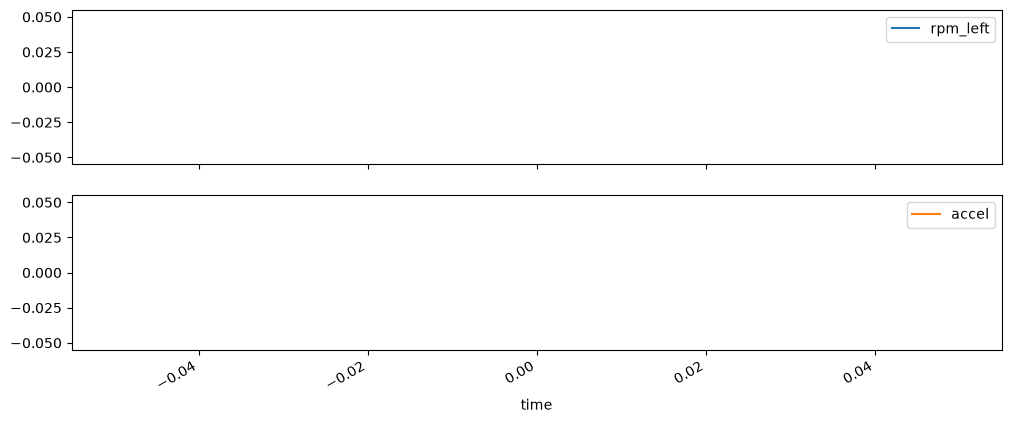

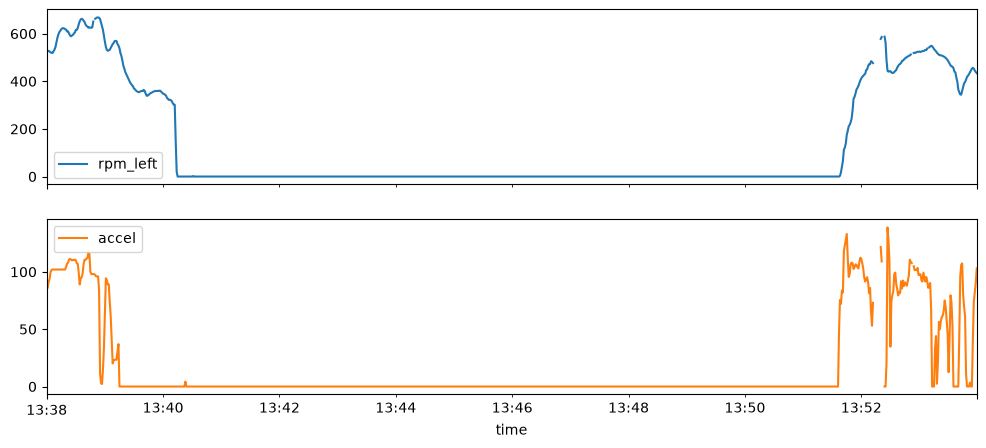

In [20]:
df.loc["2025-07-03 11:55":"2025-07-03 12:03", ["rpm_left", "accel"]].plot(subplots=True, figsize=(12, 5))
df.loc["2025-07-03 13:38":"2025-07-03 13:53", ["rpm_left", "accel"]].plot(subplots=True, figsize=(12, 5))

### Step 4 - Checking for Gaps

In [21]:
in_race = df[df["lap"] > 0]
coverage = in_race.groupby("lap")[["current", "vpack", "vmin", "rpm_left"]].agg(
    lambda s: s.notna().mean()
)
coverage.describe()

,current,vpack,vmin,rpm_left
count,49.000000,49.000000,49.000000,49.000000
mean,0.802494,0.662925,0.662270,0.795785
std,0.215170,0.187099,0.186850,0.218213
min,0.000000,0.000000,0.000000,0.000000
25%,0.804281,0.617737,0.623853,0.800623
50%,0.859649,0.699732,0.697051,0.864706
75%,0.915033,0.765579,0.762611,0.919162
max,0.989305,0.896142,0.896142,0.989305


<Axes: xlabel='lap'>

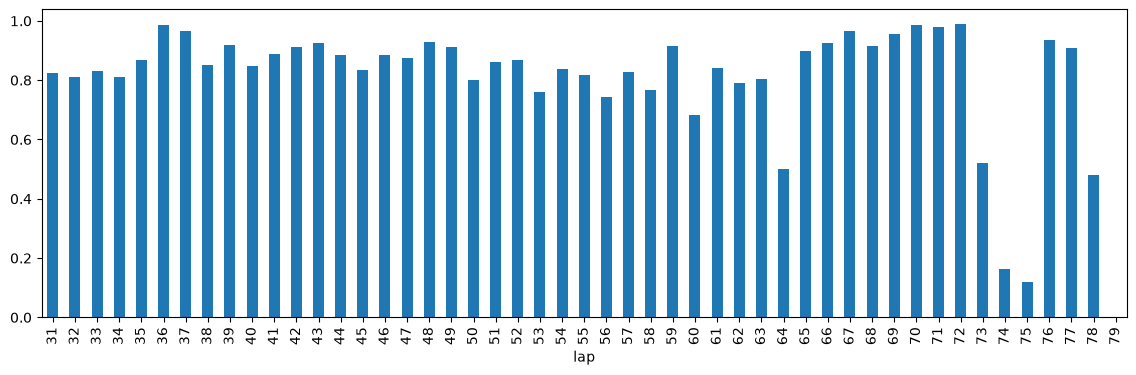

In [22]:
coverage["current"].plot(kind="bar", figsize=(14, 4))

In [23]:
missing = df["current"].isna()
gap_id = (missing != missing.shift()).cumsum()     # new id each time missing flips
gaps = (df[missing].groupby(gap_id[missing])
        .agg(start=("lap", lambda s: s.index[0]),
             length=("lap", "size"),
             lap=("lap", "first")))
gaps = gaps[gaps["lap"] > 0]                        # only gaps during laps
gaps["length"].describe()

count     610.000000
mean        6.522951
std        50.479965
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      1162.000000
Name: length, dtype: float64

<Axes: ylabel='Frequency'>

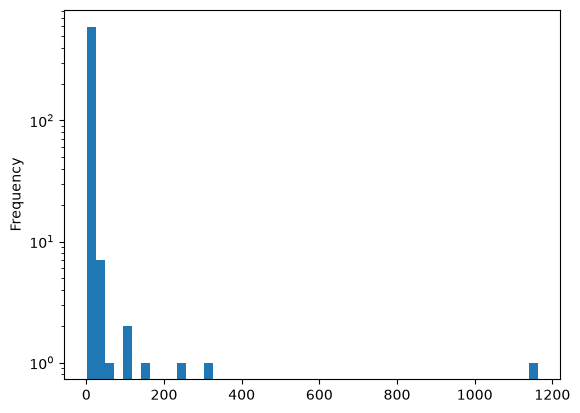

In [ ]:
gaps["length"].plot(kind="hist", bins=50, logy=True)

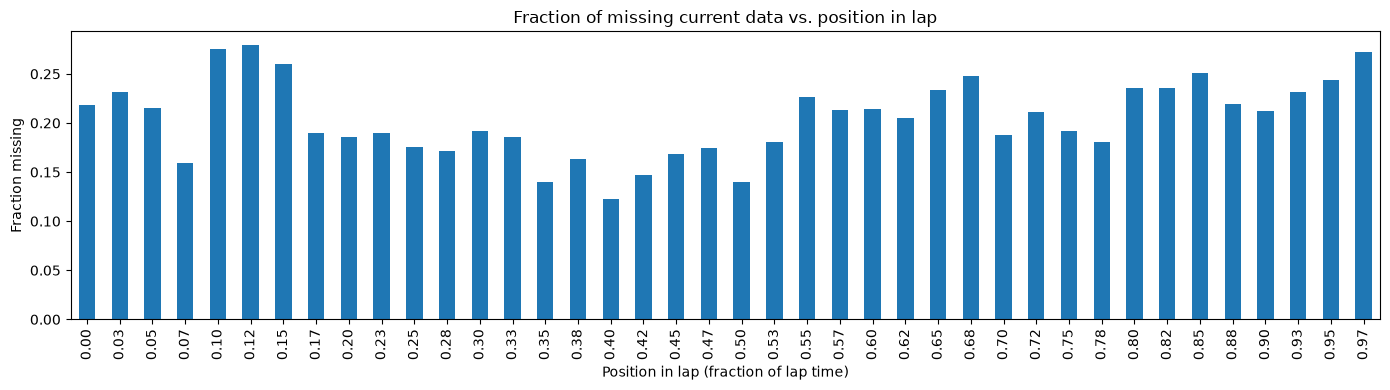

In [27]:
import matplotlib.pyplot as plt

in_race = df[df["lap"] > 0].copy()

# Position in lap: seconds since lap start / lap length (one row per second)
elapsed = in_race.groupby("lap").cumcount()
lap_len = in_race.groupby("lap")["lap"].transform("size")
in_race["lap_frac"] = elapsed / lap_len

# Fraction of missing current readings at each position around the lap
in_race["missing"] = in_race["current"].isna()
by_pos = in_race.groupby(pd.cut(in_race["lap_frac"], bins=40), observed=False)["missing"].mean()

ax = by_pos.plot(kind="bar", figsize=(14, 4),
                 title="Fraction of missing current data vs. position in lap")
ax.set_xlabel("Position in lap (fraction of lap time)")
ax.set_ylabel("Fraction missing")
ax.set_xticklabels([f"{i/40:.2f}" for i in range(40)], rotation=90)
plt.tight_layout()
plt.show()

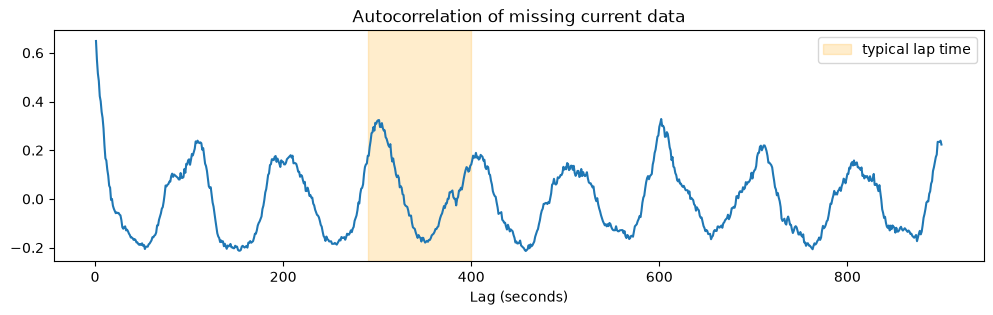

In [28]:
m = df["current"].isna().astype(float)
m = m["2025-07-03 11:00":"2025-07-03 13:35"]      # one steady stretch of racing
lags = range(1, 901)
ac = pd.Series([m.autocorr(lag) for lag in lags], index=lags)

ax = ac.plot(figsize=(12, 3), title="Autocorrelation of missing current data")
ax.set_xlabel("Lag (seconds)")
ax.axvspan(290, 400, alpha=0.2, color="orange", label="typical lap time")
ax.legend()
plt.show()

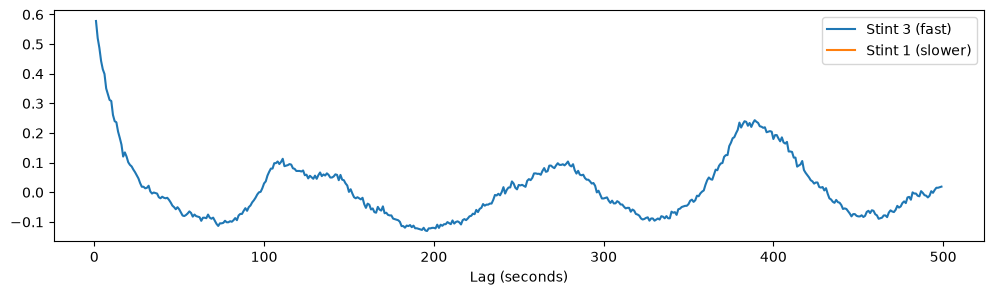

In [29]:
def missing_autocorr(start, end, max_lag=500):
    m = df["current"].isna().astype(float)[start:end]
    return pd.Series([m.autocorr(l) for l in range(1, max_lag)], index=range(1, max_lag))

fast = missing_autocorr("2025-07-03 14:00", "2025-07-03 15:25")   # stint 3, fast laps
mid  = missing_autocorr("2025-07-03 11:00", "2025-07-03 11:55")   # stint 1

ax = fast.plot(figsize=(12, 3), label="Stint 3 (fast)")
mid.plot(ax=ax, label="Stint 1 (slower)")
ax.set_xlabel("Lag (seconds)"); ax.legend(); plt.show()